# Phương pháp 3: Mở rộng sang Ma Trận Không Chéo (Fully-Connected RNN)

## Mục tiêu

Khi ma trận trạng thái $A$ có nhiều giá trị riêng, sự nhạy cảm **không chỉ tập trung vào một tham số** mà lan ra **toàn bộ phần tử** của $A$. Điều này khiến việc tối ưu càng khó hơn, ngay cả khi $A$ được ràng buộc để tránh vanishing/exploding gradients.

## Mô hình

$$h_{k+1} = A h_k + B x_k, \quad h_0 = 0$$

với $A \in \mathbb{R}^{d\times d}$ có spectral radius $\rho(A) < 1$.

Đạo hàm theo phần tử $A_{ij}$:
$$\frac{\partial h_k}{\partial A_{ij}} = \sum_{t=0}^{k-1} A^{k-1-t} E_{ij} h_t$$

trong đó $E_{ij}$ là ma trận chỉ phần tử $(i,j) = 1$, còn lại bằng 0.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

## Bước 1: Tạo ma trận A với spectral radius có kiểm soát

In [2]:
def random_matrix_with_radius(d, target_radius, structure='dense'):
    """Sinh ma trận d×d với spectral radius = target_radius."""
    if structure == 'dense':
        A = np.random.randn(d, d) / np.sqrt(d)
    elif structure == 'orthogonal':
        # ngẫu nhiên orthogonal
        Q, _ = np.linalg.qr(np.random.randn(d, d))
        A = Q
    elif structure == 'diagonal':
        A = np.diag(np.random.uniform(-1, 1, d))
    cur_radius = np.max(np.abs(np.linalg.eigvals(A)))
    A = A * (target_radius / cur_radius)
    return A

d = 8
A_dense = random_matrix_with_radius(d, 0.95, 'dense')
A_diag = random_matrix_with_radius(d, 0.95, 'diagonal')

print('Spectral radius A_dense:', np.max(np.abs(np.linalg.eigvals(A_dense))))
print('Spectral radius A_diag :', np.max(np.abs(np.linalg.eigvals(A_diag))))

Spectral radius A_dense: 0.9500000000000011
Spectral radius A_diag : 0.9500000000000001


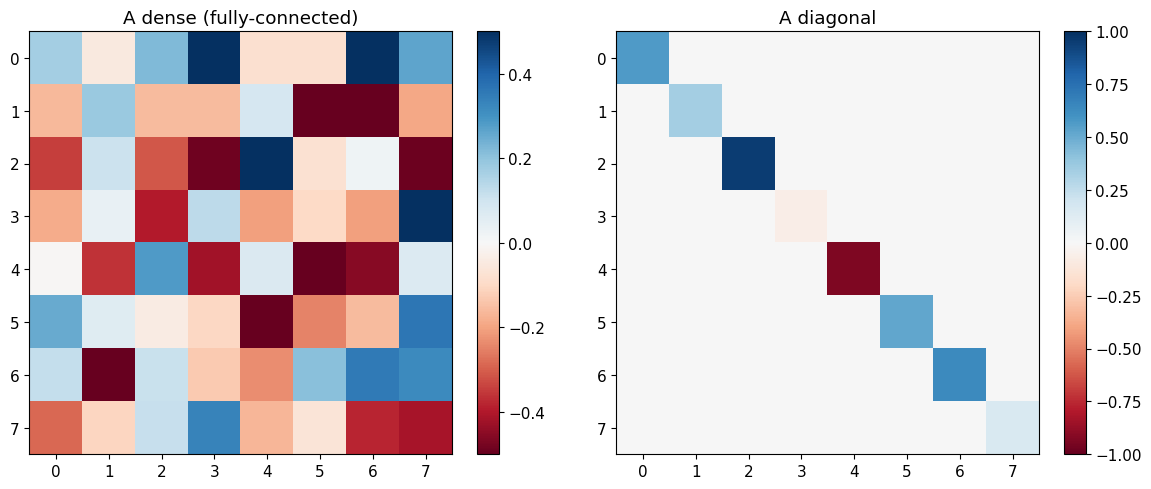

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].imshow(A_dense, cmap='RdBu', vmin=-0.5, vmax=0.5)
axes[0].set_title('A dense (fully-connected)')
plt.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(A_diag, cmap='RdBu', vmin=-1, vmax=1)
axes[1].set_title('A diagonal')
plt.colorbar(im1, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.show()

## Bước 2: Tính sensitivity ∂h_k/∂A_ij — lan ra toàn bộ ma trận

In [4]:
def simulate_rnn_mat(A, B, x):
    T = x.shape[0]
    d = A.shape[0]
    h = np.zeros((T + 1, d))
    for k in range(T):
        h[k+1] = A @ h[k] + B @ x[k]
    return h

def sensitivity_all_Aij(A, B, x):
    """Tính ||∂h_T / ∂A_ij||² cho mọi (i,j) bằng recurrence.
    Sử dụng auto-recurrence: D^{(i,j)}_{k+1} = A D^{(i,j)}_k + e_i h_k[j]"""
    T = x.shape[0]
    d = A.shape[0]
    h = simulate_rnn_mat(A, B, x)
    sens_norm = np.zeros((d, d))
    for i in range(d):
        for j in range(d):
            D = np.zeros((T + 1, d))
            for k in range(T):
                D[k+1] = A @ D[k]
                D[k+1, i] += h[k, j]
            sens_norm[i, j] = np.sum(D[-1] ** 2)
    return sens_norm, h

In [6]:
T = 60
n_in = 3
B = np.random.randn(d, n_in) / np.sqrt(n_in)
x = np.random.randn(T, n_in)

sens_dense, h_dense = sensitivity_all_Aij(A_dense, B, x)
sens_diag, h_diag = sensitivity_all_Aij(A_diag, B, x)

print('Tổng năng lượng sensitivity (dense):', sens_dense.sum())
print('Tổng năng lượng sensitivity (diag) :', sens_diag.sum())

Tổng năng lượng sensitivity (dense): 6773.458298424645
Tổng năng lượng sensitivity (diag) : 854.9103216922836


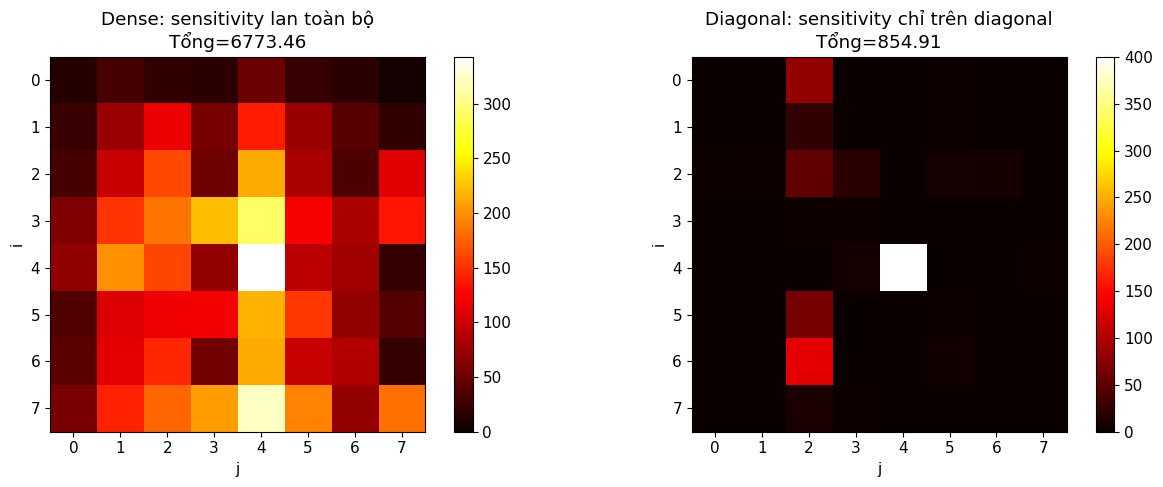

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
vmax = max(sens_dense.max(), sens_diag.max())
im0 = axes[0].imshow(sens_dense, cmap='hot', vmin=0)
axes[0].set_title(f'Dense: sensitivity lan toàn bộ\nTổng={sens_dense.sum():.2f}')
plt.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(sens_diag, cmap='hot', vmin=0)
axes[1].set_title(f'Diagonal: sensitivity chỉ trên diagonal\nTổng={sens_diag.sum():.2f}')
plt.colorbar(im1, ax=axes[1], fraction=0.046)
for ax in axes:
    ax.set_xlabel('j'); ax.set_ylabel('i')
plt.tight_layout()
plt.show()

**Quan sát**: Với ma trận dense, sensitivity ∂h_T/∂A_ij lan tỏa khắp $d \times d$ phần tử, trong khi với diagonal chỉ tập trung trên đường chéo. Điều này chứng minh ma trận fully-connected có **không gian tối ưu phức tạp hơn rất nhiều**.

## Bước 3: Phụ thuộc vào số giá trị riêng — eigenvalue clustering

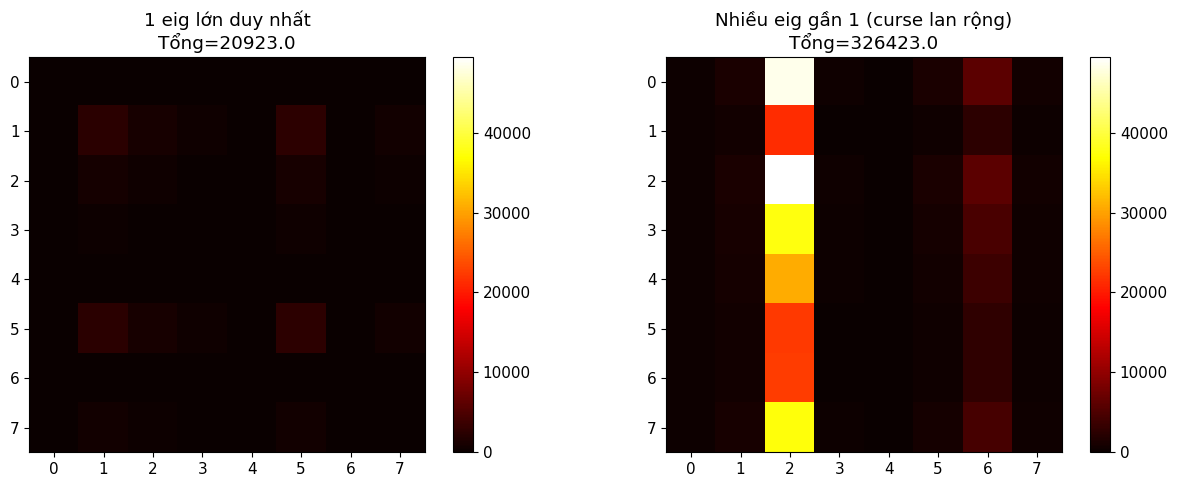


Khi nhiều giá trị riêng gần 1, curse of memory cộng dồn trên nhiều chiều.


In [8]:
def build_A_with_eigenvalues(eigs):
    d = len(eigs)
    Q, _ = np.linalg.qr(np.random.randn(d, d))
    return Q @ np.diag(eigs) @ Q.T

# Trường hợp 1: 1 giá trị riêng lớn, còn lại nhỏ
eigs_one = np.array([0.99] + [0.1] * (d-1))
# Trường hợp 2: nhiều giá trị riêng đều gần 1
eigs_many = np.array([0.99 - 0.005 * i for i in range(d)])

A1 = build_A_with_eigenvalues(eigs_one)
A2 = build_A_with_eigenvalues(eigs_many)

sens1, _ = sensitivity_all_Aij(A1, B, x)
sens2, _ = sensitivity_all_Aij(A2, B, x)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
vmax = max(sens1.max(), sens2.max())
im0 = axes[0].imshow(sens1, cmap='hot', vmin=0, vmax=vmax)
axes[0].set_title(f'1 eig lớn duy nhất\nTổng={sens1.sum():.1f}')
plt.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(sens2, cmap='hot', vmin=0, vmax=vmax)
axes[1].set_title(f'Nhiều eig gần 1 (curse lan rộng)\nTổng={sens2.sum():.1f}')
plt.colorbar(im1, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.show()
print('\nKhi nhiều giá trị riêng gần 1, curse of memory cộng dồn trên nhiều chiều.')

## Bước 4: Curse spread với constraint orthogonal

Một cách thử để ổn định: ràng buộc $A$ là orthogonal (||A|| = 1, không vanishing/exploding). Nhưng curse of memory vẫn xảy ra!

Spectral radius orthogonal: 0.990000000000001
Tổng sensitivity         : 45544.27396615463
Tổng sensitivity (diag)  : 854.9103216922836
Tỉ số ortho/diag         : 53.27374440397485


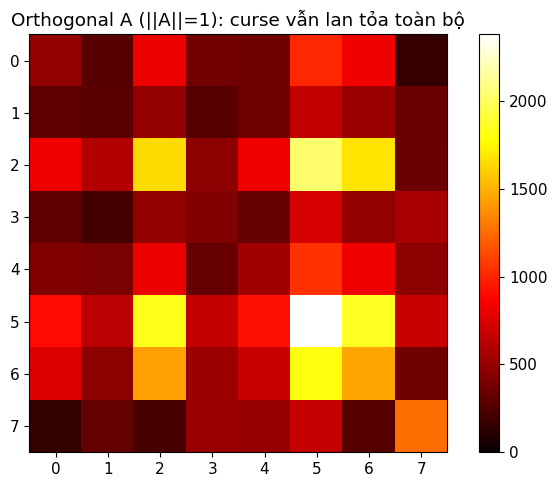

In [9]:
# Orthogonal matrix với spectral radius gần 1
Q_ortho, _ = np.linalg.qr(np.random.randn(d, d))
A_ortho = 0.99 * Q_ortho

sens_ortho, _ = sensitivity_all_Aij(A_ortho, B, x)
print('Spectral radius orthogonal:', np.max(np.abs(np.linalg.eigvals(A_ortho))))
print('Tổng sensitivity         :', sens_ortho.sum())
print('Tổng sensitivity (diag)  :', sens_diag.sum())
print('Tỉ số ortho/diag         :', sens_ortho.sum() / sens_diag.sum())

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(sens_ortho, cmap='hot', vmin=0)
ax.set_title('Orthogonal A (||A||=1): curse vẫn lan tỏa toàn bộ')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## Bước 5: Quét spectral radius — chứng minh bùng nổ khi gần 1

  0%|          | 0/20 [00:00<?, ?it/s]

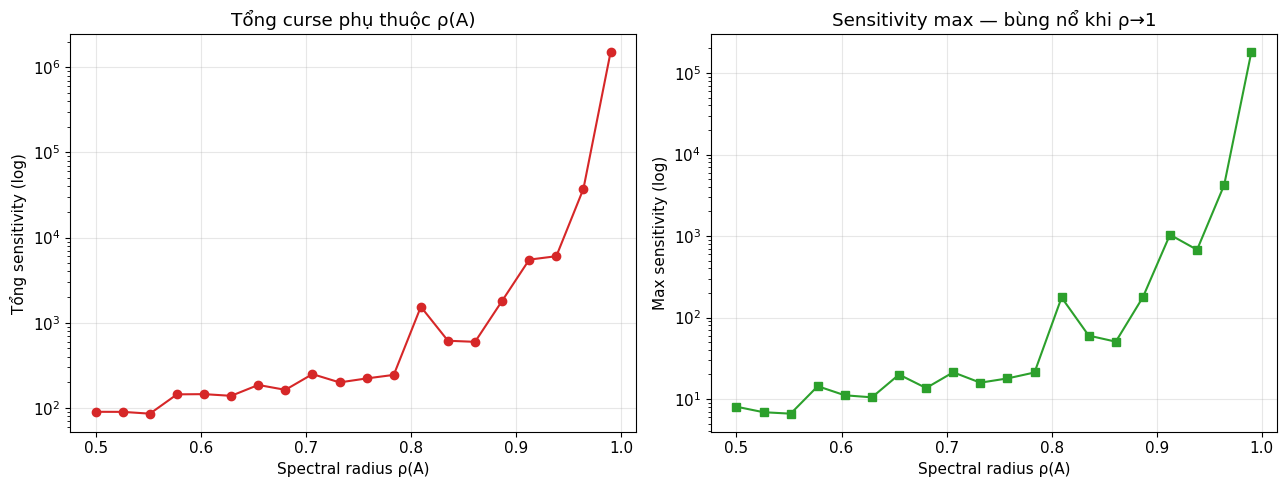

In [10]:
radii = np.linspace(0.5, 0.99, 20)
T_test = 100
n_trials = 10

total_sens = []
max_sens = []
for r in tqdm(radii):
    runs = []
    runs_max = []
    for _ in range(n_trials):
        A_r = random_matrix_with_radius(d, r, 'dense')
        x_r = np.random.randn(T_test, n_in)
        s, _ = sensitivity_all_Aij(A_r, B, x_r)
        runs.append(s.sum())
        runs_max.append(s.max())
    total_sens.append(np.mean(runs))
    max_sens.append(np.mean(runs_max))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(radii, total_sens, 'o-', color='C3')
axes[0].set_yscale('log')
axes[0].set_xlabel('Spectral radius ρ(A)')
axes[0].set_ylabel('Tổng sensitivity (log)')
axes[0].set_title('Tổng curse phụ thuộc ρ(A)')
axes[0].grid(alpha=0.3)

axes[1].plot(radii, max_sens, 's-', color='C2')
axes[1].set_yscale('log')
axes[1].set_xlabel('Spectral radius ρ(A)')
axes[1].set_ylabel('Max sensitivity (log)')
axes[1].set_title('Sensitivity max — bùng nổ khi ρ→1')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Kết luận phương pháp 3

- Với **ma trận A đơn vị/chéo**, curse of memory chỉ tập trung tại một phần tử duy nhất.
- Với **ma trận A dense (fully-connected)**, curse **lan tỏa khắp $d^2$ phần tử** → không gian tối ưu trở nên phức tạp hơn nhiều bậc.
- Ngay cả với ràng buộc **orthogonal** ($\|A\|=1$), curse vẫn tồn tại và lan tỏa.
- Khi nhiều giá trị riêng gần 1, curse cộng dồn → bất ổn càng nặng.
- Đây là lý do tại sao các kiến trúc **LRU, S4, SSMs** dùng cấu trúc gần-chéo (diagonal/diagonal-plus-low-rank) thay vì dense — để giới hạn không gian curse.